In [2]:
!pip install git+https://github.com/ScaleAGData/scaleag-vito.git@prometheo-integration --extra-index-url https://pypi.org/simple --timeout 60 --no-cache-dir


Looking in indexes: https://artifactory.vgt.vito.be/artifactory/api/pypi/python-packages/simple, https://pypi.org/simple
  Cloning https://github.com/ScaleAGData/scaleag-vito.git (to revision prometheo-integration) to /tmp/pip-req-build-8nz_un8s
  Running command git clone --filter=blob:none --quiet https://github.com/ScaleAGData/scaleag-vito.git /tmp/pip-req-build-8nz_un8s
  Running command git checkout -b prometheo-integration --track origin/prometheo-integration
  Switched to a new branch 'prometheo-integration'
  branch 'prometheo-integration' set up to track 'origin/prometheo-integration'.
  Resolved https://github.com/ScaleAGData/scaleag-vito.git to commit ad1c0b6f4d9125059574659f56b557d28a0f74c5
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/WorldCereal/prometheo.git to /tmp/pip-install-5bc0216r/prometheo_8e9fd1467ae84f7ca8d7477b5837ee29
  Running command git clon

In [3]:
!pip install git+https://github.com/WorldCereal/prometheo.git@main --no-cache-dir --timeout 60

Looking in indexes: https://artifactory.vgt.vito.be/artifactory/api/pypi/python-packages/simple
  Cloning https://github.com/WorldCereal/prometheo.git (to revision main) to /tmp/pip-req-build-_y98_x5c
  Running command git clone --filter=blob:none --quiet https://github.com/WorldCereal/prometheo.git /tmp/pip-req-build-_y98_x5c
  Resolved https://github.com/WorldCereal/prometheo.git to commit 99b7bbd1bf6d3d68d0be36550c8bab94a890ff19
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [4]:
from loguru import logger
import geopandas as gpd
from pathlib import Path

# scaleag-vito package imports
from scaleagdata_vito.openeo.extract_sample_scaleag import (
    generate_input_for_extractions,
    extract
)
from scaleagdata_vito.presto.presto_df import load_dataset
from scaleagdata_vito.presto.utils import evaluate_finetuned_model, evaluate_downstream_model, get_encodings

# prometheo package imports
from prometheo.datasets.scaleag import ScaleAgDataset
from prometheo import finetune
from prometheo.finetune import Hyperparams
from prometheo.models.presto import param_groups_lrd
from prometheo.models.presto.wrapper import PretrainedPrestoWrapper  # load_presto_weights is manually defined

# torch imports
from torch import nn
from torch.optim import AdamW, lr_scheduler
from torch.utils.data import DataLoader

# other ML imports
import catboost as CB


In [5]:
def check_unique_id(df_path, unique_id):
    df = gpd.read_file(df_path)
    if df[unique_id].nunique() != df.shape[0]:
        logger.info("IDs are not unique!")
        return df[df[unique_id].duplicated(keep=False)]
    else:
        logger.info("IDs are unique")
        return None

def check_valid_geometry(df):
    if isinstance(df, str):
        df = gpd.read_file(df)
    df_invalid = df[~df.geometry.is_valid]
    # Assessing wheather some invalid geometries are present
    if len(df_invalid) > 0:
        # 1) some invalid geometries are present. Attempt fixing them
        df['geometry'] = df.geometry.buffer(0)
        df_invalid = df[~df.geometry.is_valid]
        df_valid = df[df.geometry.is_valid]
        if len(df_invalid) > 0:
            # 2) Still some invalid geometries are present. Return them
            logger.info("Invalid geometries found! Returning invalid geometries")
            return df_invalid, df_valid
        else:
            # All geometries are now valid. Return fixed dataframe and empty dataframe for invalid geometries
            logger.info("Fixed some invalid geometries. All geometries are now valid")
            return gpd.GeoDataFrame(), df
    else:
        # All geometries are valid. Return empty dataframe for invalid geometries
        logger.info("All geometries are valid")
        return gpd.GeoDataFrame(), df

def _save(save_to, original_file_path, df, suffix=''):
    if suffix!='':
        filename = Path(save_to) / f"{Path(original_file_path).stem}_{suffix}.geojson"
    else:
        filename = Path(save_to) / f"{Path(original_file_path).stem}.geojson"
    logger.info(f"Saving invalid geometries to {filename}")
    Path(save_to).mkdir(parents=True, exist_ok=True)
    df.to_file(filename)

In [6]:
input_file = "/home/theonarh/GEOMaize.git/data/correct/Maize_North_Ghana_valid.geojson"
invalid_geom, valid_geom = check_valid_geometry(input_file)
non_unique_ids = check_unique_id(input_file, unique_id="Field_id")

2025-06-10 09:04:18.931 | INFO     | __main__:check_valid_geometry:30 - All geometries are valid
2025-06-10 09:04:18.966 | INFO     | __main__:check_unique_id:7 - IDs are unique


In [7]:
from pathlib import Path
import openeo
from scaleagdata_vito.openeo.extract_sample_scaleag import extract, generate_input_for_extractions
import logging

# === Setup logging (optional) ===
logging.basicConfig(level=logging.INFO)

# === Step 1: Ensure output directory exists ===
outdir = "/home/theonarh/GEOMaize.git/data/geomaize/extractions_North_Ghana/"
output_path = Path(outdir)
output_path.mkdir(parents=True, exist_ok=True)

# === Step 2: Authenticate with OpenEO CDSE (with extended timeout) ===
conn = openeo.connect("https://openeo.dataspace.copernicus.eu")
conn.authenticate_oidc(max_poll_time=300)  # 5 minutes timeout

# Optional: Save connection to use inside the extraction module if needed
# For some wrappers you may need to inject this into the job manager directly

# === Step 3: Define extraction parameters ===
task_type = "regression"
start_date = "2021-07-01"
end_date = "2021-10-31"
composite_window = "dekad"
unique_id_column = "Field_id"
input_df = "/home/theonarh/GEOMaize.git/data/correct/Maize_North_Ghana_valid.geojson"
output_folder = outdir

job_params = dict(
    output_folder=output_folder,
    input_df=input_df,
    start_date=start_date,
    end_date=end_date,
    unique_id_column=unique_id_column,
    composite_window=composite_window,
)

# === Step 4: Run the extraction ===
extract(generate_input_for_extractions(job_params))


INFO:openeo.config:Loaded openEO client config from sources: []
INFO:openeo.rest.connection:Found OIDC providers: ['CDSE']
INFO:openeo.rest.connection:No OIDC provider given, but only one available: 'CDSE'. Using that one.
INFO:openeo.rest.connection:Using default client_id 'sh-b1c3a958-52d4-40fe-a333-153595d1c71e' from OIDC provider 'CDSE' info.
INFO:openeo.rest.connection:Found refresh token: trying refresh token based authentication.
INFO:openeo.rest.auth.oidc:Doing 'refresh_token' token request 'https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token' with post data fields ['grant_type', 'client_id', 'refresh_token'] (client_id 'sh-b1c3a958-52d4-40fe-a333-153595d1c71e')
INFO:openeo.rest.connection:Obtained tokens: ['access_token', 'id_token', 'refresh_token']
INFO:openeo.rest.auth.config:Storing refresh token for issuer 'https://identity.dataspace.copernicus.eu/auth/realms/CDSE' (client 'sh-b1c3a958-52d4-40fe-a333-153595d1c71e')
2025-06-10 09:05:15,8

Authenticated using refresh token.


In [9]:
from pathlib import Path
import openeo
from scaleagdata_vito.openeo.extract_sample_scaleag import extract, generate_input_for_extractions
from scaleagdata_vito.presto.presto_df import load_dataset
import logging
import pandas as pd

# === Setup logging ===
logging.basicConfig(level=logging.INFO)

# === Output path setup ===
outdir = "/home/theonarh/GEOMaize.git/data/geomaize/extractions_North_Ghana/"
output_path = Path(outdir)
output_path.mkdir(parents=True, exist_ok=True)

# === Authenticate OpenEO ===
conn = openeo.connect("https://openeo.dataspace.copernicus.eu")
conn.authenticate_oidc(max_poll_time=300)  # 5 minutes timeout

# === Extraction parameters ===
task_type = "regression"
start_date = "2021-07-01"
end_date = "2021-10-31"
composite_window = "dekad"
unique_id_column = "Field_id"
input_df = "/home/theonarh/GEOMaize.git/data/correct/Maize_North_Ghana_valid.geojson"
output_folder = outdir

job_params = dict(
    output_folder=output_folder,
    input_df=input_df,
    start_date=start_date,
    end_date=end_date,
    unique_id_column=unique_id_column,
    composite_window=composite_window,
)

# === Run the extraction ===
extract(generate_input_for_extractions(job_params))

# === Debug output directory ===
print(f"\n🔍 Listing contents of {outdir} ...")
files = list(output_path.glob("**/*"))
for f in files:
    print(f"- {f.relative_to(output_path)}")

# === Load geoparquet files ===
def safe_load_geoparquet_dataset(path):
    geo_files = list(Path(path).rglob("*.geoparquet"))
    if not geo_files:
        print(f"\n No .geoparquet files found in: {path}")
        return None
    # Concatenate all geoparquet files
    dfs = [pd.read_parquet(fp) for fp in geo_files]
    return pd.concat(dfs, ignore_index=True)

df = safe_load_geoparquet_dataset(outdir)

if df is not None:
    print(f"\n Dataset loaded successfully with shape: {df.shape}")
else:
    print("\n Dataset not loaded. Ensure that .geoparquet files were generated.")


INFO:openeo.rest.connection:Found OIDC providers: ['CDSE']
INFO:openeo.rest.connection:No OIDC provider given, but only one available: 'CDSE'. Using that one.
INFO:openeo.rest.connection:Using default client_id 'sh-b1c3a958-52d4-40fe-a333-153595d1c71e' from OIDC provider 'CDSE' info.
INFO:openeo.rest.connection:Found refresh token: trying refresh token based authentication.
INFO:openeo.rest.auth.oidc:Doing 'refresh_token' token request 'https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token' with post data fields ['grant_type', 'client_id', 'refresh_token'] (client_id 'sh-b1c3a958-52d4-40fe-a333-153595d1c71e')
INFO:openeo.rest.connection:Obtained tokens: ['access_token', 'id_token', 'refresh_token']
INFO:openeo.rest.auth.config:Storing refresh token for issuer 'https://identity.dataspace.copernicus.eu/auth/realms/CDSE' (client 'sh-b1c3a958-52d4-40fe-a333-153595d1c71e')
2025-06-10 09:07:52,230|extraction_pipeline|INFO:  Loading input dataframe from /home

Authenticated using refresh token.

🔍 Listing contents of /home/theonarh/GEOMaize.git/data/geomaize/extractions_North_Ghana/ ...
- job_tracking.csv
- failed_jobs
- 30
- failed_jobs/ScaleAgData_Geometry_Extraction_30PYR_j-25060422081644cc905d8161d0534224.log
- 30/30PYR
- 30/30PZR
- 30/30PYR/SCALEAG_extractions_North_Ghana_2021-07-01_2021-10-31_30PYR_j-2506042208354b93a1ce9ad48d53d700.geoparquet
- 30/30PYR/SCALEAG_extractions_North_Ghana_2021-07-01_2021-10-31_30PYR_j-2506042210554ce8a6535b3426047052.geoparquet
- 30/30PYR/SCALEAG_extractions_North_Ghana_2021-07-01_2021-10-31_30PYR_j-2506042214184da28b700138f1e3d01b.geoparquet
- 30/30PZR/SCALEAG_extractions_North_Ghana_2021-07-01_2021-10-31_30PZR_j-2506042218404a769076bbb82d654a86.geoparquet

 Dataset loaded successfully with shape: (1596, 33)


In [10]:
df.head()

,feature_index,S2-L2A-B02,S2-L2A-B03,S2-L2A-B04,S2-L2A-B05,S2-L2A-B06,S2-L2A-B07,S2-L2A-B08,S2-L2A-B8A,S2-L2A-B11,...,Crop,Type,COMMUNITY,Year,tile,Field_id,Season,lat,start_date,timestamp
0,0,65535,65535,65535,65535,65535,65535,65535,65535,65535,...,Maize,Mono Cropping,Chambuligu,2021,30PYR,4009CHA,July-October,9.218397,2021-07-01,2021-09-01 00:00:00+00:00
1,1,65535,65535,65535,65535,65535,65535,65535,65535,65535,...,Maize,Mono Cropping,Chambuligu,2021,30PYR,4047CHA,July-October,9.218051,2021-07-01,2021-09-01 00:00:00+00:00
2,2,65535,65535,65535,65535,65535,65535,65535,65535,65535,...,Maize,Mono Cropping,Chambuligu,2021,30PYR,4051CHA,July-October,9.220596,2021-07-01,2021-09-01 00:00:00+00:00
3,3,65535,65535,65535,65535,65535,65535,65535,65535,65535,...,Maize,Mono Cropping,Chambuligu,2021,30PYR,4050CHA,July-October,9.218463,2021-07-01,2021-09-01 00:00:00+00:00
4,4,65535,65535,65535,65535,65535,65535,65535,65535,65535,...,Maize,Mono Cropping,Chambuligu,2021,30PYR,4048CHA,July-October,9.219466,2021-07-01,2021-09-01 00:00:00+00:00


In [11]:
df.columns

Index(['feature_index', 'S2-L2A-B02', 'S2-L2A-B03', 'S2-L2A-B04', 'S2-L2A-B05',
       'S2-L2A-B06', 'S2-L2A-B07', 'S2-L2A-B08', 'S2-L2A-B8A', 'S2-L2A-B11',
       'S2-L2A-B12', 'S1-SIGMA0-VH', 'S1-SIGMA0-VV', 'slope', 'elevation',
       'AGERA5-PRECIP', 'AGERA5-TMEAN', 'geometry', 'Area(acre)', 'end_date',
       'sample_id', 'lon', 'REGION', 'Crop', 'Type', 'COMMUNITY', 'Year',
       'tile', 'Field_id', 'Season', 'lat', 'start_date', 'timestamp'],
      dtype='object')

In [12]:
col = ['S2-L2A-B02', 'S2-L2A-B03', 'S2-L2A-B04', 'S2-L2A-B05',
       'S2-L2A-B06', 'S2-L2A-B07', 'S2-L2A-B08', 'S2-L2A-B8A', 'S2-L2A-B11',
       'S2-L2A-B12', 'S1-SIGMA0-VH', 'elevation']
df[col]

,S2-L2A-B02,S2-L2A-B03,S2-L2A-B04,S2-L2A-B05,S2-L2A-B06,S2-L2A-B07,S2-L2A-B08,S2-L2A-B8A,S2-L2A-B11,S2-L2A-B12,S1-SIGMA0-VH,S1-SIGMA0-VV,slope,elevation
0,65535,65535,65535,65535,65535,65535,65535,65535,65535,65535,2728,5591,0,124
1,65535,65535,65535,65535,65535,65535,65535,65535,65535,65535,2660,4978,0,125
2,65535,65535,65535,65535,65535,65535,65535,65535,65535,65535,2543,4961,0,121
3,65535,65535,65535,65535,65535,65535,65535,65535,65535,65535,2535,4807,0,124
4,65535,65535,65535,65535,65535,65535,65535,65535,65535,65535,2539,4568,0,123
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1591,341,717,519,1214,2625,2976,2910,3274,2157,1187,2734,5148,0,201
1592,65535,65535,65535,65535,65535,65535,65535,65535,65535,65535,2678,4998,0,201
1593,65535,65535,65535,65535,65535,65535,65535,65535,65535,65535,2806,5413,0,201
1594,459,874,728,1562,2931,3230,3237,3562,2463,1402,2975,5094,0,201


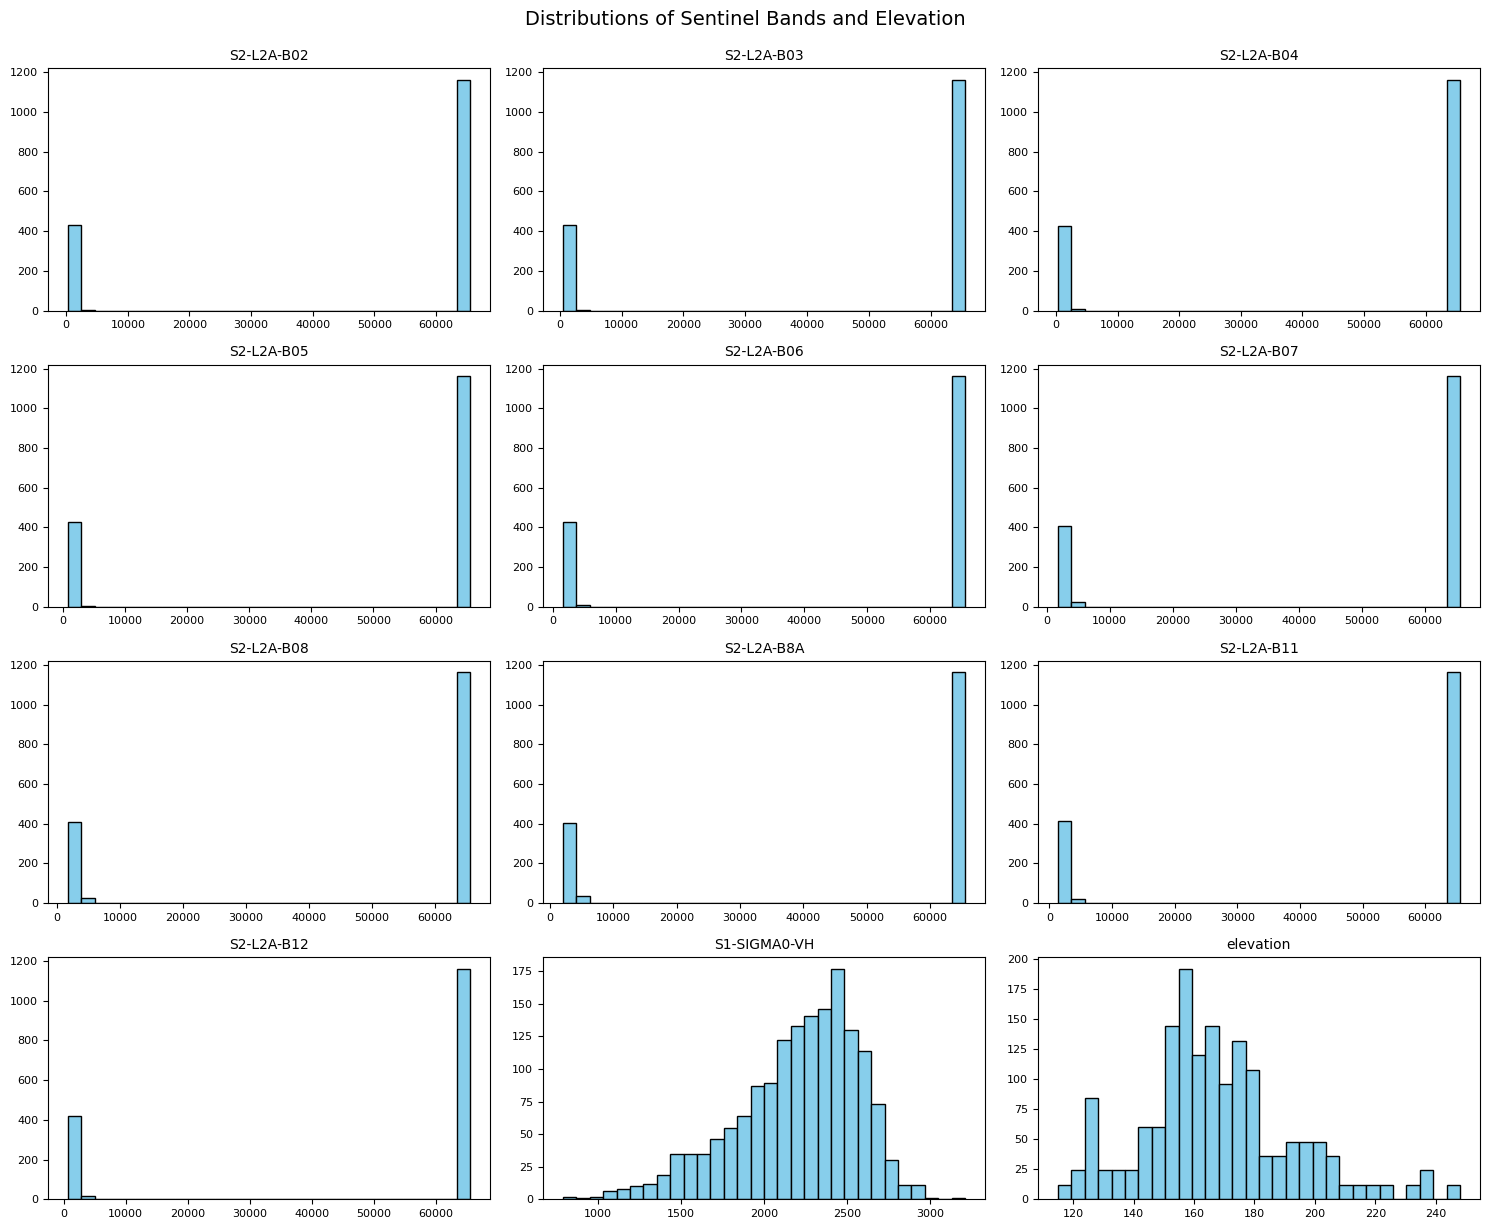

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming df is already defined and contains the columns
col = ['S2-L2A-B02', 'S2-L2A-B03', 'S2-L2A-B04', 'S2-L2A-B05',
       'S2-L2A-B06', 'S2-L2A-B07', 'S2-L2A-B08', 'S2-L2A-B8A',
       'S2-L2A-B11', 'S2-L2A-B12', 'S1-SIGMA0-VH', 'elevation']

# Create 4x3 subplots
fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.flatten()

for i, band in enumerate(col):
    axes[i].hist(df[band].dropna(), bins=30, color='skyblue', edgecolor='black')
    axes[i].set_title(band, fontsize=10)
    axes[i].tick_params(axis='both', labelsize=8)

# Turn off any unused subplots (if fewer than 12 columns)
for j in range(len(col), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.suptitle('Distributions of Sentinel Bands and Elevation', fontsize=14, y=1.02)
plt.show()


In [14]:
df[col].describe().T

,count,mean,std,min,25%,50%,75%,max
S2-L2A-B02,1596.0,47869.981830,28914.365401,278.0,942.50,65535.0,65535.0,65535.0
S2-L2A-B03,1596.0,47976.272556,28740.353869,527.0,1243.75,65535.0,65535.0,65535.0
S2-L2A-B04,1596.0,47951.932331,28780.458157,338.0,1235.25,65535.0,65535.0,65535.0
S2-L2A-B05,1596.0,48135.280702,28480.237773,817.0,1891.25,65535.0,65535.0,65535.0
S2-L2A-B06,1596.0,48475.508772,27923.729439,1621.0,3350.00,65535.0,65535.0,65535.0
S2-L2A-B07,1596.0,48574.563283,27761.911370,1810.0,3829.00,65535.0,65535.0,65535.0
S2-L2A-B08,1596.0,48551.806391,27799.248545,1724.0,3750.75,65535.0,65535.0,65535.0
S2-L2A-B8A,1596.0,48637.903509,27658.443703,2012.0,4108.00,65535.0,65535.0,65535.0
S2-L2A-B11,1596.0,48443.060777,27977.068313,1382.0,3191.75,65535.0,65535.0,65535.0
S2-L2A-B12,1596.0,48175.934837,28414.546064,702.0,2255.75,65535.0,65535.0,65535.0


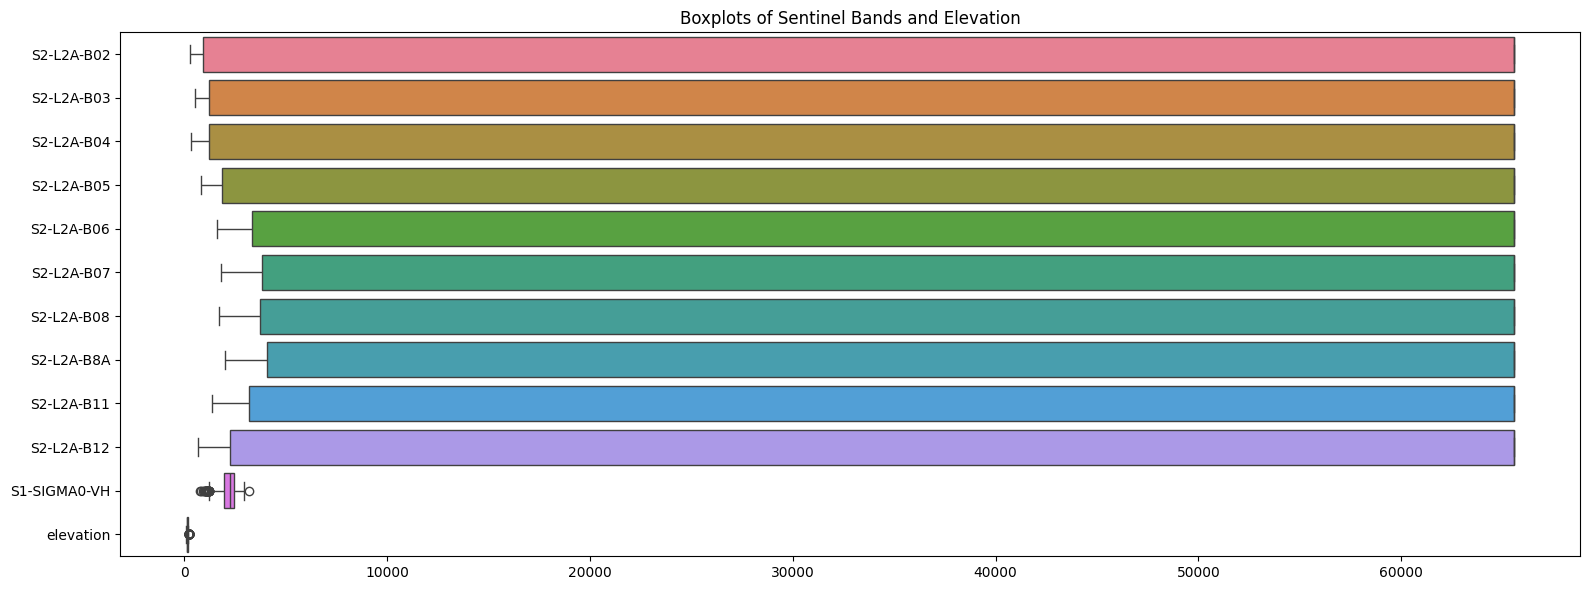

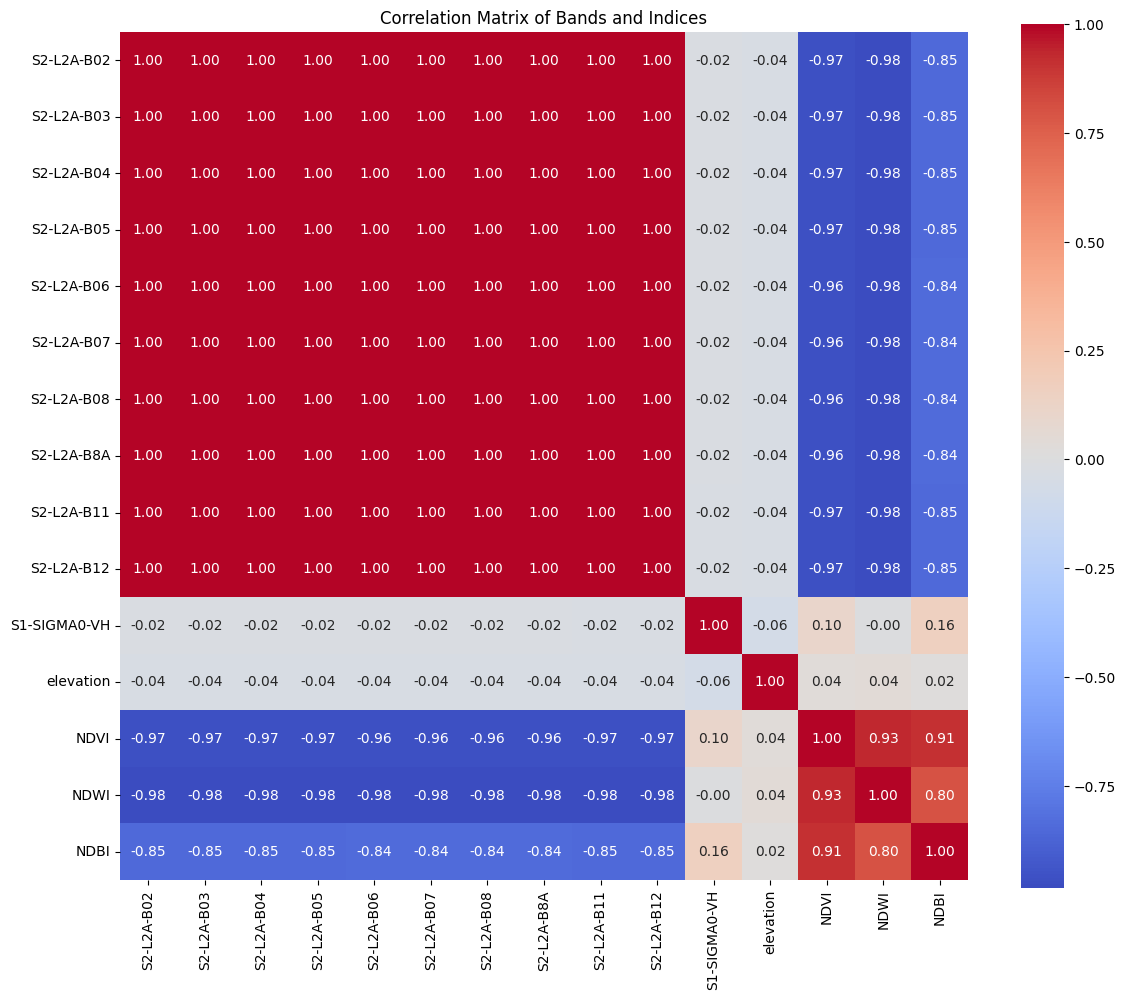

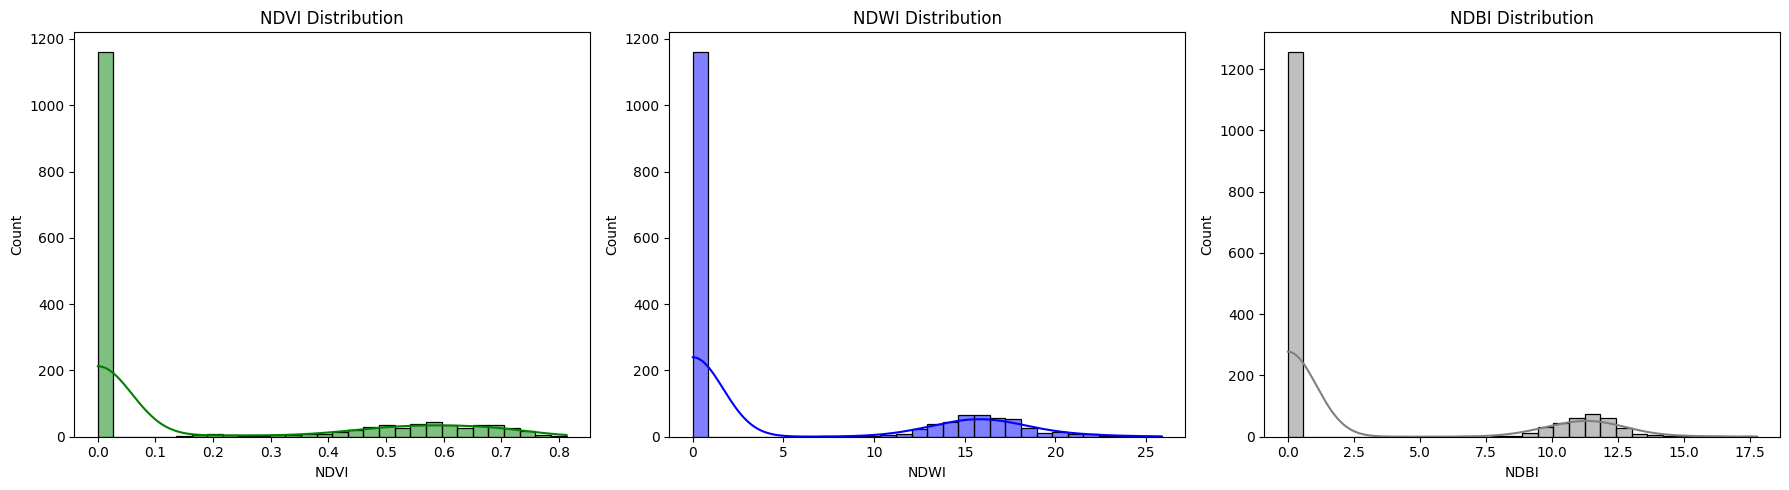

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# Define column names
cols = ['S2-L2A-B02', 'S2-L2A-B03', 'S2-L2A-B04', 'S2-L2A-B05',
        'S2-L2A-B06', 'S2-L2A-B07', 'S2-L2A-B08', 'S2-L2A-B8A', 'S2-L2A-B11',
        'S2-L2A-B12', 'S1-SIGMA0-VH', 'elevation']


# Calculate NDVI, NDWI, and NDBI
df['NDVI'] = (df['S2-L2A-B08'] - df['S2-L2A-B04']) / (df['S2-L2A-B08'] + df['S2-L2A-B04'] + 1e-10)
df['NDWI'] = (df['S2-L2A-B03'] - df['S2-L2A-B08']) / (df['S2-L2A-B03'] + df['S2-L2A-B08'] + 1e-10)
df['NDBI'] = (df['S2-L2A-B11'] - df['S2-L2A-B08']) / (df['S2-L2A-B11'] + df['S2-L2A-B08'] + 1e-10)

# Plot 1: Boxplots
plt.figure(figsize=(16, 6))
sns.boxplot(data=df[cols], orient='h')
plt.title('Boxplots of Sentinel Bands and Elevation')
plt.tight_layout()
plt.show()

# Plot 2: Correlation Heatmap
plt.figure(figsize=(12, 10))
corr_matrix = df[cols + ['NDVI', 'NDWI', 'NDBI']].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix of Bands and Indices')
plt.tight_layout()
plt.show()

# Plot 3: NDVI, NDWI, NDBI Distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['NDVI'], bins=30, ax=axes[0], kde=True, color='green')
axes[0].set_title('NDVI Distribution')
sns.histplot(df['NDWI'], bins=30, ax=axes[1], kde=True, color='blue')
axes[1].set_title('NDWI Distribution')
sns.histplot(df['NDBI'], bins=30, ax=axes[2], kde=True, color='gray')
axes[2].set_title('NDBI Distribution')
plt.tight_layout()
plt.show()


### Using GeoDataFrame

In [17]:
from pathlib import Path
import openeo
from scaleagdata_vito.openeo.extract_sample_scaleag import extract, generate_input_for_extractions
import geopandas as gpd
import logging

# === Setup logging ===
logging.basicConfig(level=logging.INFO)

# === Output path setup ===
outdir = "/home/theonarh/GEOMaize.git/data/geomaize/extractions_North_Ghana/"
output_path = Path(outdir)
output_path.mkdir(parents=True, exist_ok=True)

# === Authenticate OpenEO ===
conn = openeo.connect("https://openeo.dataspace.copernicus.eu")
conn.authenticate_oidc(max_poll_time=300)  # 5 minutes timeout

# === Extraction parameters ===
task_type = "regression"
start_date = "2021-07-01"
end_date = "2021-10-31"
composite_window = "dekad"
unique_id_column = "Field_id"
input_df = "/home/theonarh/GEOMaize.git/data/correct/Maize_North_Ghana_valid.geojson"
output_folder = outdir

job_params = dict(
    output_folder=output_folder,
    input_df=input_df,
    start_date=start_date,
    end_date=end_date,
    unique_id_column=unique_id_column,
    composite_window=composite_window,
)

# === Run the extraction ===
extract(generate_input_for_extractions(job_params))

# === Debug: list contents ===
print(f"\n🔍 Listing contents of {outdir} ...")
files = list(output_path.glob("**/*"))
for f in files:
    print(f"- {f.relative_to(output_path)}")

# === Load .geoparquet files into GeoDataFrame ===
def load_geoparquet_as_gdf(path):
    geo_files = list(Path(path).rglob("*.geoparquet"))
    if not geo_files:
        print(f"\n No .geoparquet files found in: {path}")
        return None
    # Load and concatenate all files as GeoDataFrames
    gdfs = [gpd.read_parquet(fp) for fp in geo_files]
    return gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs=gdfs[0].crs)

gdf = load_geoparquet_as_gdf(outdir)

# === Check result ===
if gdf is not None:
    print(f"\n GeoDataFrame loaded successfully with shape: {gdf.shape}")
    print(f"CRS: {gdf.crs}")
else:
    print("\nGeoDataFrame not loaded. Ensure that .geoparquet files were generated.")


INFO:openeo.rest.connection:Found OIDC providers: ['CDSE']
INFO:openeo.rest.connection:No OIDC provider given, but only one available: 'CDSE'. Using that one.
INFO:openeo.rest.connection:Using default client_id 'sh-b1c3a958-52d4-40fe-a333-153595d1c71e' from OIDC provider 'CDSE' info.
INFO:openeo.rest.connection:Found refresh token: trying refresh token based authentication.
INFO:openeo.rest.auth.oidc:Doing 'refresh_token' token request 'https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token' with post data fields ['grant_type', 'client_id', 'refresh_token'] (client_id 'sh-b1c3a958-52d4-40fe-a333-153595d1c71e')
INFO:openeo.rest.connection:Obtained tokens: ['access_token', 'id_token', 'refresh_token']
INFO:openeo.rest.auth.config:Storing refresh token for issuer 'https://identity.dataspace.copernicus.eu/auth/realms/CDSE' (client 'sh-b1c3a958-52d4-40fe-a333-153595d1c71e')
2025-06-10 09:49:00,730|extraction_pipeline|INFO:  Loading input dataframe from /home

Authenticated using refresh token.

🔍 Listing contents of /home/theonarh/GEOMaize.git/data/geomaize/extractions_North_Ghana/ ...
- job_tracking.csv
- failed_jobs
- 30
- failed_jobs/ScaleAgData_Geometry_Extraction_30PYR_j-25060422081644cc905d8161d0534224.log
- 30/30PYR
- 30/30PZR
- 30/30PYR/SCALEAG_extractions_North_Ghana_2021-07-01_2021-10-31_30PYR_j-2506042208354b93a1ce9ad48d53d700.geoparquet
- 30/30PYR/SCALEAG_extractions_North_Ghana_2021-07-01_2021-10-31_30PYR_j-2506042210554ce8a6535b3426047052.geoparquet
- 30/30PYR/SCALEAG_extractions_North_Ghana_2021-07-01_2021-10-31_30PYR_j-2506042214184da28b700138f1e3d01b.geoparquet
- 30/30PZR/SCALEAG_extractions_North_Ghana_2021-07-01_2021-10-31_30PZR_j-2506042218404a769076bbb82d654a86.geoparquet

 GeoDataFrame loaded successfully with shape: (1596, 33)
CRS: {"$schema": "https://proj.org/schemas/v0.6/projjson.schema.json", "type": "GeographicCRS", "name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"

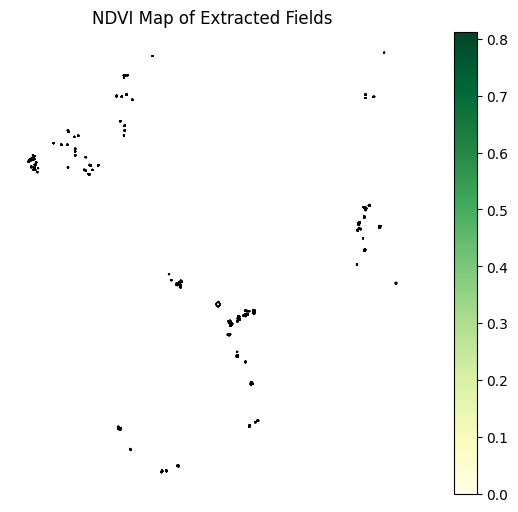

In [18]:
import matplotlib.pyplot as plt
# Compute NDVI from Sentinel-2 bands
gdf["NDVI"] = (gdf["S2-L2A-B08"] - gdf["S2-L2A-B04"]) / (gdf["S2-L2A-B08"] + gdf["S2-L2A-B04"])

# Plot NDVI spatially
gdf.plot(column="NDVI", cmap="YlGn", legend=True, figsize=(10, 6), edgecolor='black')
plt.title("NDVI Map of Extracted Fields")
plt.axis('off')
plt.show()


In [19]:
avg_ndvi_per_crop = gdf.groupby("Crop")["NDVI"].mean().sort_values(ascending=False)
print(avg_ndvi_per_crop)


Crop
maize    0.161467
Maize    0.139275
Name: NDVI, dtype: float64


In [20]:
np.unique(gdf["Crop"].values)

array(['Maize', 'maize'], dtype=object)

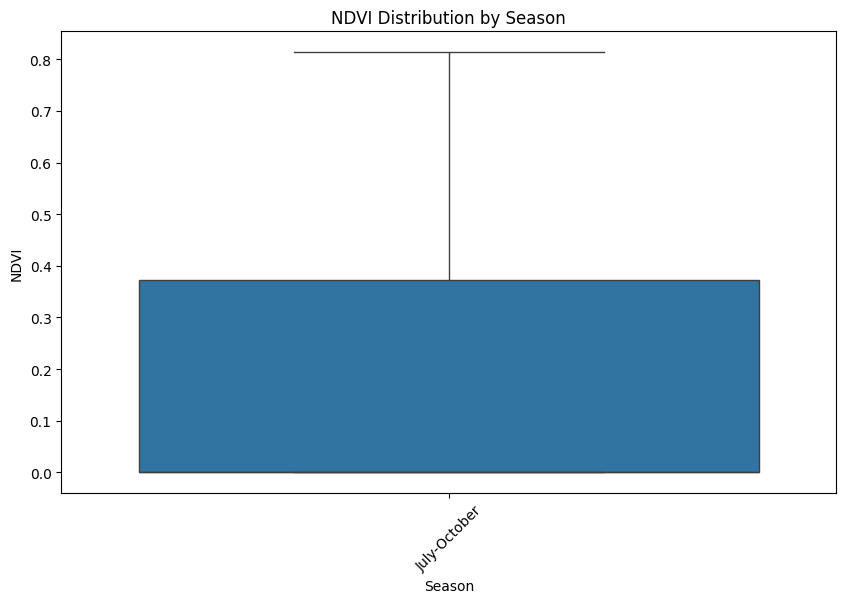

In [21]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(data=gdf, x="Season", y="NDVI")
plt.title("NDVI Distribution by Season")
plt.xticks(rotation=45)
plt.show()
